In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [2]:
S = 100  # Current stock price
K = 100  # Strike price
T = 1    # Time to expiration in years
r = 0.05  # Risk-free interest rate
sigma = 0.2  # Volatility of the underlying stock

In [3]:
d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

print(f"d1: {d1}, d2: {d2}")

call = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
print(f"Call option price: {call}")

d1: 0.35000000000000003, d2: 0.15000000000000002
Call option price: 10.450583572185565


In [4]:
put = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
print(f"Put option price: {put}")

Put option price: 5.573526022256971


In [5]:
np.isclose(call - put, S - K * np.exp(-r * T))

np.True_

In [6]:
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return call_price, put_price

black_scholes_call(S, K, T, r, sigma)

(np.float64(10.450583572185565), np.float64(5.573526022256971))

In [7]:
def delta(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    if option_type == 'call':
        return norm.cdf(d1)
    elif option_type == 'put':
        return norm.cdf(d1) - 1
    else:
        raise ValueError("option_type must be 'call' or 'put'")

delta(S, K, T, r, sigma, option_type='put')

np.float64(-0.3631693488243809)

In [8]:
def gamma(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

gamma(S, K, T, r, sigma)

np.float64(0.018762017345846895)

In [9]:
def vega(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

vega(S, K, T, r, sigma)

np.float64(37.52403469169379)

In [10]:
def theta(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return ((-S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * norm.cdf(d2)) / 365

theta(S, K, T, r, sigma)

np.float64(-0.017946553235672853)

In [11]:
def greeks(S, K, T, r, sigma):
    print(f"Call Price: {black_scholes_call(S, K, T, r, sigma)[0]:.4f}")
    print(f"Put Price: {black_scholes_call(S, K, T, r, sigma)[1]:.4f}")
    print(f"Delta (Call): {delta(S, K, T, r, sigma, option_type='call'):.4f}")
    print(f"Gamma: {gamma(S, K, T, r, sigma):.4f}")
    print(f"Vega: {vega(S, K, T, r, sigma):.4f}")
    print(f"Theta: {theta(S, K, T, r, sigma):.4f}")

greeks(S, K, T, r, sigma)

Call Price: 10.4506
Put Price: 5.5735
Delta (Call): 0.6368
Gamma: 0.0188
Vega: 37.5240
Theta: -0.0179


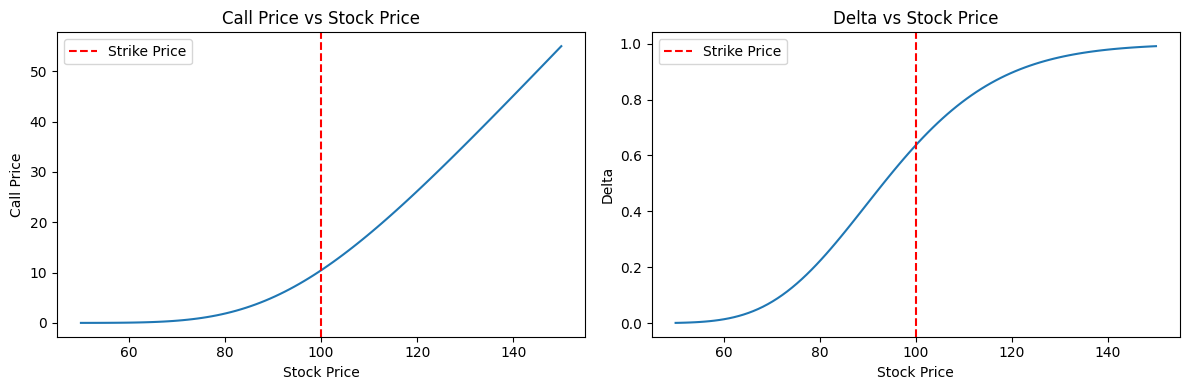

In [13]:
stock_prices = np.linspace(50, 150, 100)

call_prices = [black_scholes_call(S_i, K, T, r, sigma)[0] for S_i in stock_prices]
deltas = [delta(S_i, K, T, r, sigma) for S_i in stock_prices]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(stock_prices, call_prices)
ax1.axvline(x=K, color='red', linestyle='--', label='Strike Price')
ax1.set_title('Call Price vs Stock Price')
ax1.set_xlabel('Stock Price')
ax1.set_ylabel('Call Price')
ax1.legend()

ax2.plot(stock_prices, deltas)
ax2.axvline(x=K, color='red', linestyle='--', label='Strike Price')
ax2.set_title('Delta vs Stock Price')
ax2.set_xlabel('Stock Price')
ax2.set_ylabel('Delta')
ax2.legend()

plt.tight_layout()
plt.show()


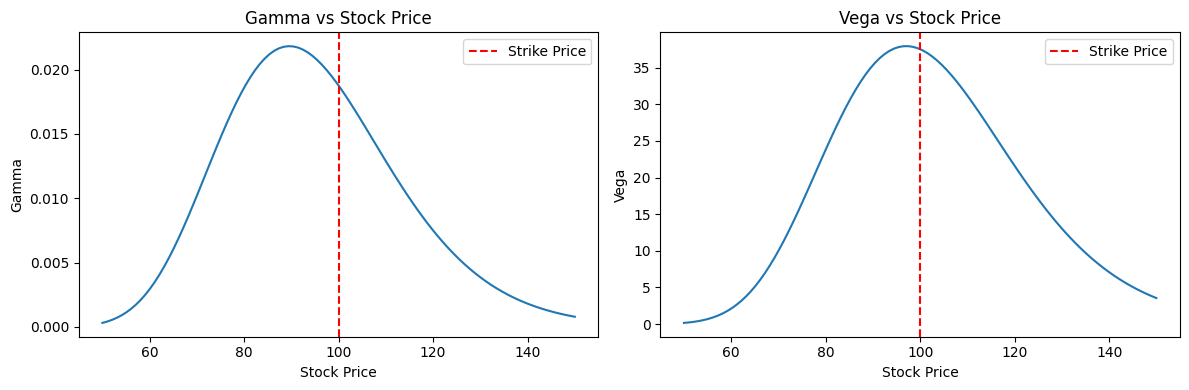

In [15]:
gammas = [gamma(S_i, K, T, r, sigma) for S_i in stock_prices]
vegas = [vega(S_i, K, T, r, sigma) for S_i in stock_prices]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(stock_prices, gammas)
ax1.axvline(x=K, color='red', linestyle='--', label='Strike Price')
ax1.set_title('Gamma vs Stock Price')
ax1.set_xlabel('Stock Price')
ax1.set_ylabel('Gamma')
ax1.legend()

ax2.plot(stock_prices, vegas)
ax2.axvline(x=K, color='red', linestyle='--', label='Strike Price')
ax2.set_title('Vega vs Stock Price')
ax2.set_xlabel('Stock Price')
ax2.set_ylabel('Vega')
ax2.legend()

plt.tight_layout()
plt.show()


In [29]:
def monte_carlos(S, K, T, r, sigma, simulations=10000):
    Z = np.random.standard_normal(simulations)
    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    call_payoffs = np.maximum(ST - K, 0)
    put_payoffs = np.maximum(K - ST, 0)
    call_price = np.exp(-r * T) * np.mean(call_payoffs)
    put_price = np.exp(-r * T) * np.mean(put_payoffs)
    return call_price, put_price

mc_call, mc_put = monte_carlos(S, K, T, r, sigma)
bs_call, bs_put = black_scholes_call(S, K, T, r, sigma)

print(f"Monte Carlo Call: {mc_call:.4f}")
print(f"Black-Scholes Call: {bs_call:.4f}")
print(f"Monte Carlo Put: {mc_put:.4f}")
print(f"Black-Scholes Put: {bs_put:.4f}")

Monte Carlo Call: 10.2905
Black-Scholes Call: 10.4506
Monte Carlo Put: 5.6118
Black-Scholes Put: 5.5735


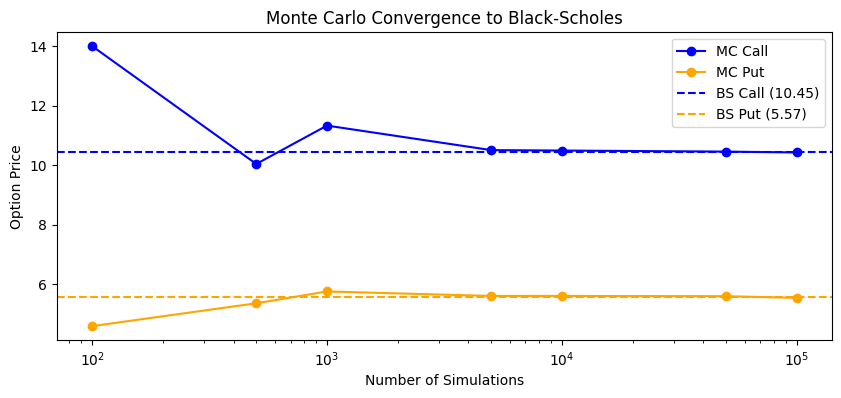

In [36]:
mc_call_prices = [monte_carlos(S, K, T, r, sigma, simulations=n)[0] for n in simulation_sizes]
mc_put_prices = [monte_carlos(S, K, T, r, sigma, simulations=n)[1] for n in simulation_sizes]

plt.figure(figsize=(10, 4))
plt.plot(simulation_sizes, mc_call_prices, marker='o', color='blue', label='MC Call')
plt.plot(simulation_sizes, mc_put_prices, marker='o', color='orange', label='MC Put')
plt.axhline(y=bs_call, color='blue', linestyle='--', label=f'BS Call ({bs_call:.2f})')
plt.axhline(y=bs_put, color='orange', linestyle='--', label=f'BS Put ({bs_put:.2f})')
plt.xscale('log')
plt.xlabel('Number of Simulations')
plt.ylabel('Option Price')
plt.title('Monte Carlo Convergence to Black-Scholes')
plt.legend()
plt.show()